## Study_1: Predict the age of an abalone (a marine snail) from easy-to-measure physical attributes.

### Install dependencies

In [1]:
# Step 1: Install dependencies
!pip install shap xgboost scikit-learn pandas matplotlib seaborn -q


### Import libraries

In [2]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

shap.initjs()


### Data

In [3]:
url = "https://raw.githubusercontent.com/iqram20/ComputerAidedAnalysis/main/resources/Week_7/abalone.csv"
df = pd.read_csv(url, header=None)

print("Shape:", df.shape)
df.head()


Shape: (4177, 9)


,0,1,2,3,4,5,6,7,8
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


### Feature Naming

In [4]:
# Step 2: Add column names for better readability
column_names = [
    "Sex", "Length", "Diameter", "Height",
    "WholeWeight", "ShuckedWeight", "VisceraWeight",
    "ShellWeight", "Rings"
]
df.columns = column_names


### Data Preprocessing

In [5]:
# Step 3: Encode 'Sex' to numeric (for modeling later)
df["Sex"] = df["Sex"].map({"M": 0, "F": 1, "I": 2})


### Feature Scatterplots

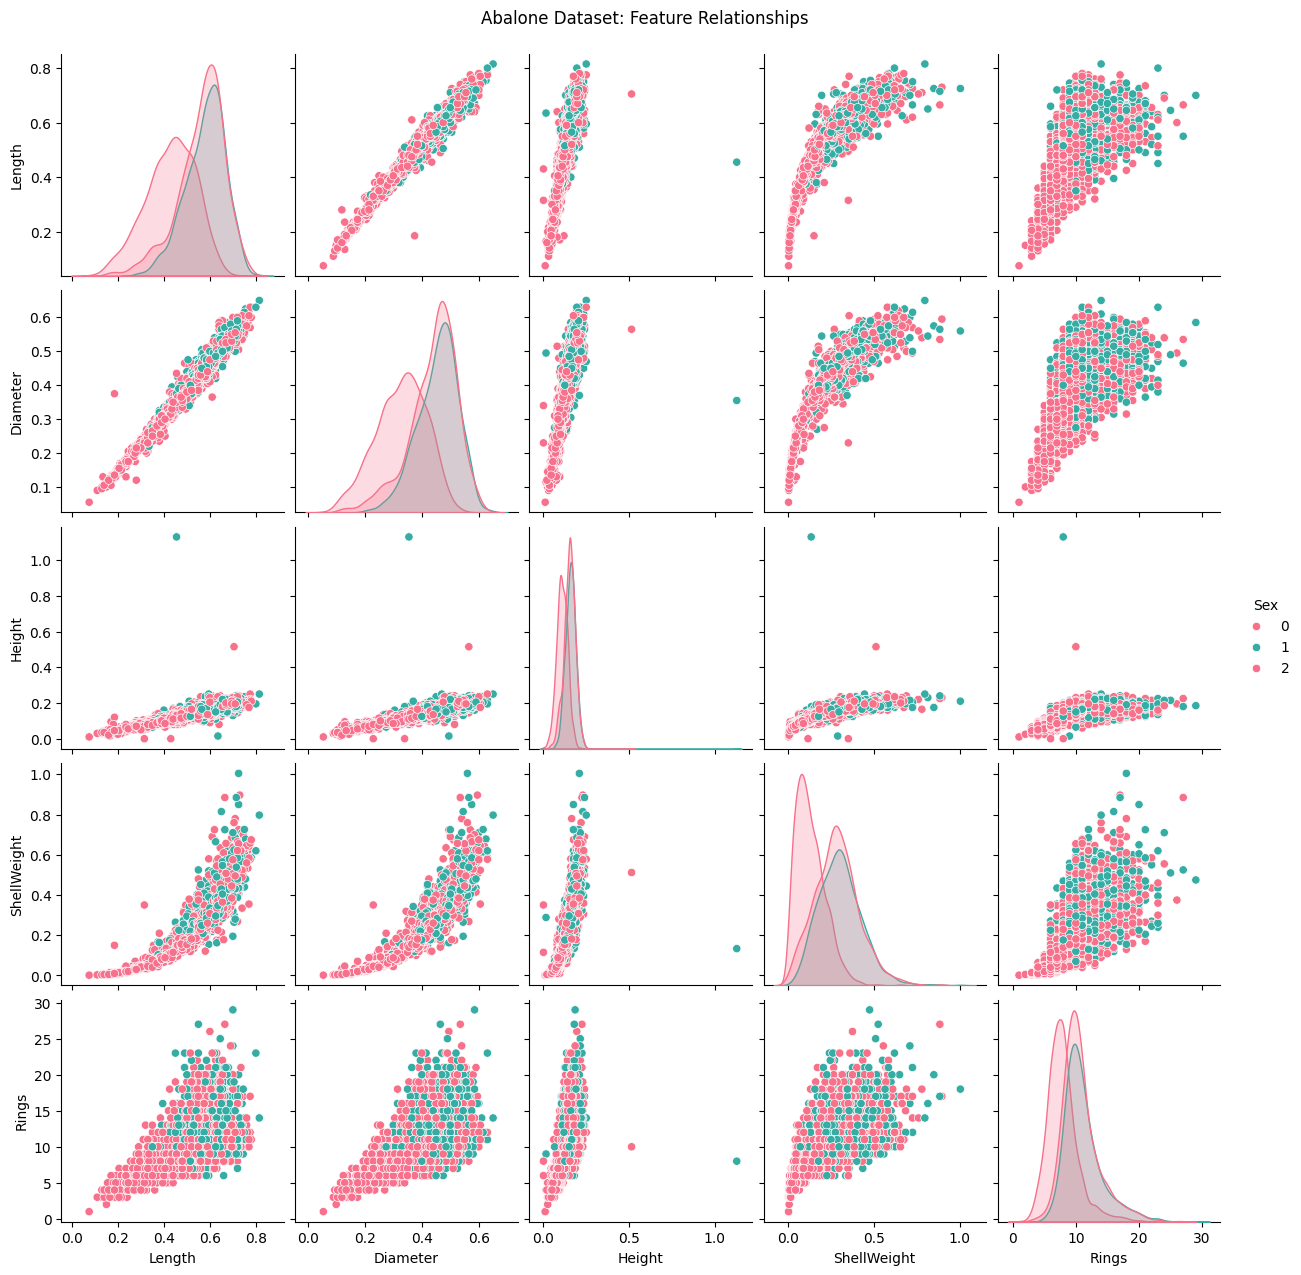

In [6]:
sns.pairplot(
    df,
    vars=["Length", "Diameter", "Height", "ShellWeight", "Rings"],
    hue="Sex",
    palette="husl",
    diag_kind="kde"
)
plt.suptitle("Abalone Dataset: Feature Relationships", y=1.02)
plt.show()


### Class Defination and Data Partition

In [7]:
# Step 2: Prepare data


X = df.iloc[:, :-1]
y = df.iloc[:, -1]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


### Model Training and Testing

R² value: 0.499


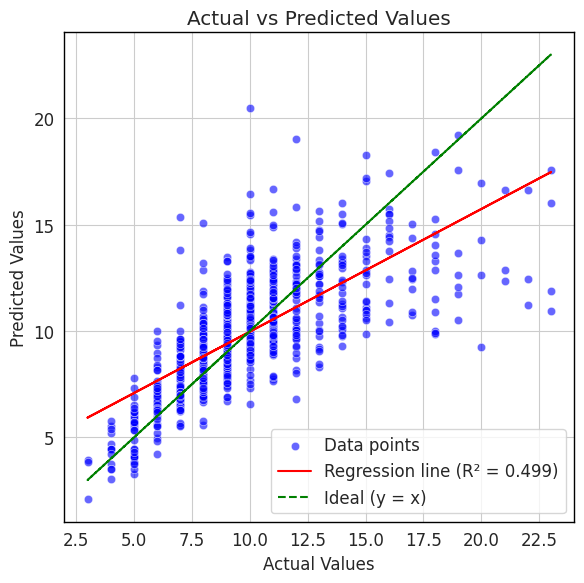

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Compute R²
r2 = r2_score(y_test, pred)
print(f"R² value: {r2:.3f}")

# Scatter plot of actual vs predicted
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=pred, color="blue", alpha=0.6, label="Data points")

# Fit regression line for visualization
reg_line = LinearRegression().fit(np.array(y_test).reshape(-1, 1), pred)
y_line = reg_line.predict(np.array(y_test).reshape(-1, 1))

# Plot regression and reference lines
plt.plot(y_test, y_line, color="red", label=f"Regression line (R² = {r2:.3f})")
plt.plot(y_test, y_test, color="green", linestyle="--", label="Ideal (y = x)")

# Labels and style
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Explaiable Machine Learning (SHAP)

ExactExplainer explainer: 837it [04:02,  3.38it/s]


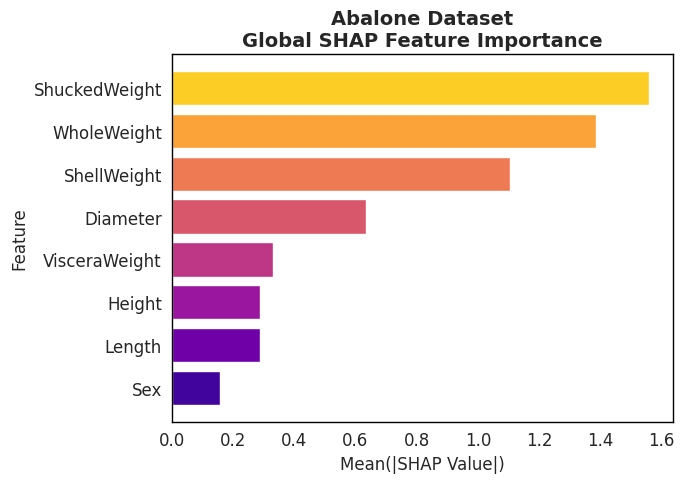

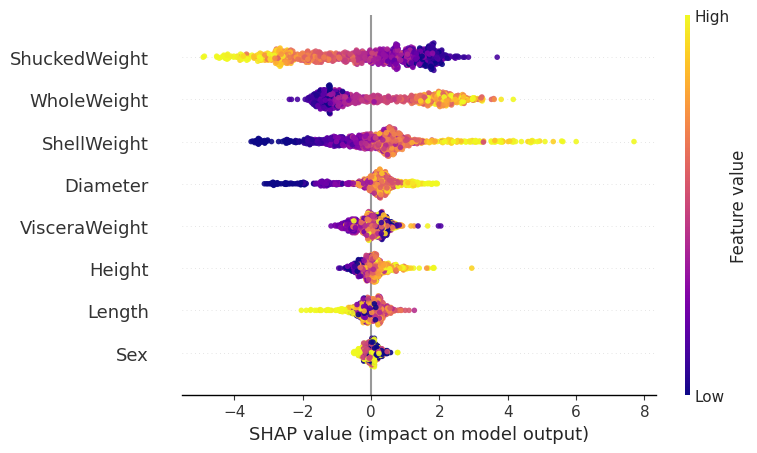

In [11]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_shap_nature(model, X, title_prefix):
    shap.initjs()
    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 12,
        "axes.edgecolor": "black",
        "axes.linewidth": 1,
        "axes.facecolor": "white",
        "figure.facecolor": "white"
    })

    # Background (masker) for model-agnostic explainer
    # Use a small representative sample to keep it fast
    if isinstance(X, pd.DataFrame):
        background = X.sample(min(200, len(X)), random_state=0)
        feature_names = X.columns
    else:
        # if X is a numpy array
        idx = np.random.default_rng(0).choice(X.shape[0], size=min(200, X.shape[0]), replace=False)
        background = X[idx]
        feature_names = [f"Feature {i}" for i in range(X.shape[1])]

    # Robust explainer that avoids XGBoost base_score issue
    explainer = shap.Explainer(model.predict, background)
    shap_values = explainer(X)   # SHAP values for the full X passed in

    # ---- 1) Global importance (custom bar with unified 'plasma' colors)
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    order = np.argsort(mean_abs_shap)[::-1]
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(feature_names)))

    plt.figure(figsize=(7, 5))
    names_ordered = np.array(feature_names)[order]
    vals_ordered = mean_abs_shap[order]
    plt.barh(names_ordered, vals_ordered, color=colors[::-1])
    plt.xlabel("Mean(|SHAP Value|)", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.title(f"{title_prefix}\nGlobal SHAP Feature Importance", fontsize=14, weight="bold")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ---- gap between figures
    plt.close()
    plt.figure(figsize=(0.01, 0.01)); plt.axis("off"); plt.show()

    # ---- 2) Beeswarm with the same 'plasma' colormap
    shap.summary_plot(shap_values, X, cmap="plasma", alpha=0.9, show=True)

plot_shap_nature(model, X_test, "Abalone Dataset")


## Study_2: Predicting Passenger Car Mileage Using XGBoost with SHAP-Based Interpretability

In [16]:
# ==== Setup & Data ====
import pandas as pd, numpy as np, glob, os
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### Data Reading (Course Git)

In [19]:
EXCEL_PATH = "https://raw.githubusercontent.com/iqram20/ComputerAidedAnalysis/main/resources/Week_7/Passenger%20Car%20Mileage%20Data.xlsx"


df = pd.read_excel(EXCEL_PATH)

### Feature Selection and Data Partition

In [20]:
# Keep only necessary columns (rename if your file uses lowercase/etc.)
expected = ["MPG","VOL","HP","SP","WT"]
cols_lower = {c.lower(): c for c in df.columns}
# Try a forgiving select (handles upper/lower names)
rename_map = {}
for c in expected:
    if c in df.columns:
        continue
    if c.lower() in cols_lower:
        rename_map[cols_lower[c.lower()]] = c
if rename_map:
    df = df.rename(columns=rename_map)

X = df[["VOL","HP","SP","WT"]].copy()
y = df["MPG"].astype(float)

# Train/val split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Model Training

In [22]:
# ==== Model ====
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

### Model Evaluate

In [23]:
# ==== Evaluate ====
pred = model.predict(X_test)
r2 = r2_score(y_test, pred)
mse = mean_squared_error(y_test, pred)
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")

R²: 0.7118
MSE: 27.6771


###Actual vs Predicted with regression line & R²

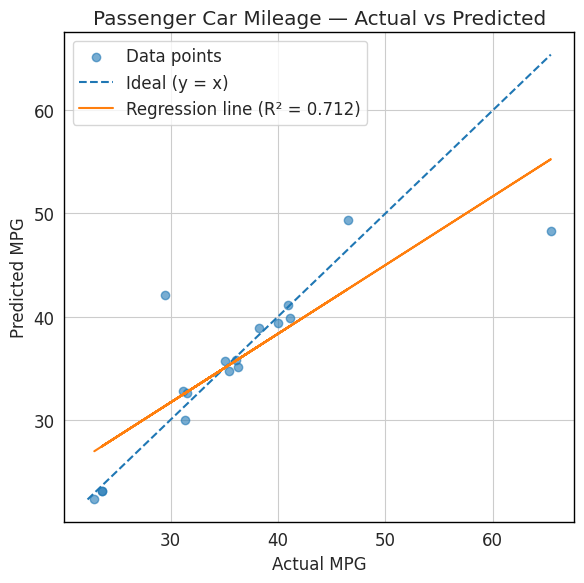

In [24]:
# ==== Plot: Actual vs Predicted with regression line & R² ====
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.6, label="Data points")

# 1:1 reference line
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims, linestyle="--", label="Ideal (y = x)")

# Regression line (pred = a*actual + b) just for visualization
lr = LinearRegression().fit(np.array(y_test).reshape(-1,1), pred)
y_line = lr.predict(np.array(y_test).reshape(-1,1))
plt.plot(y_test, y_line, label=f"Regression line (R² = {r2:.3f})")

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Passenger Car Mileage — Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Explaiable Machine Learning (SHAP)

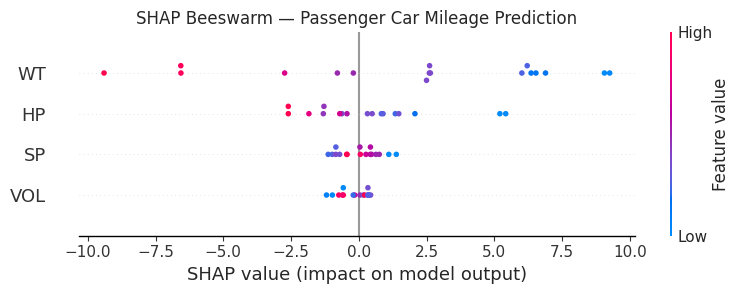


                         NEXT PLOT: SHAP FEATURE IMPORTANCE



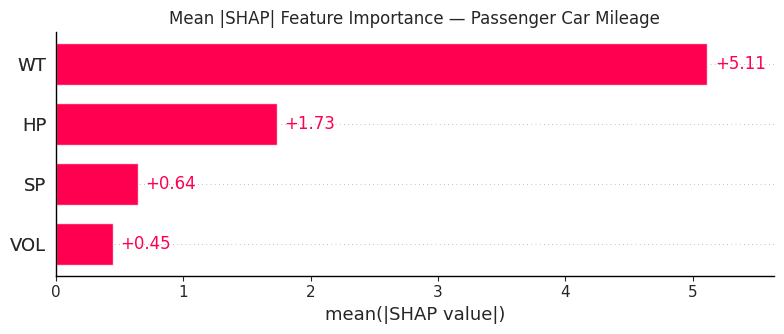

In [31]:
import shap
import matplotlib.pyplot as plt

# --- Compute SHAP values (robust) ---
bg = X_train.sample(min(200, len(X_train)), random_state=0)
explainer = shap.explainers.Permutation(model.predict, bg)
sv = explainer(X_test)

# === 1️⃣ Beeswarm Plot ===
shap.plots.beeswarm(sv, max_display=12, show=False)
plt.title("SHAP Beeswarm — Passenger Car Mileage Prediction", fontsize=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300)
plt.show()

# ---- Add a clean visual gap in the console ----
print("\n" + "="*80)
print(" " * 25 + "NEXT PLOT: SHAP FEATURE IMPORTANCE")
print("="*80 + "\n")

# === 2️⃣ Feature Importance Plot ===
plt.figure(figsize=(7,5))
shap.plots.bar(sv, max_display=12, show=False)
plt.title("Mean |SHAP| Feature Importance — Passenger Car Mileage", fontsize=12)
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=300)
plt.show()


## Study_3: Classifying Passenger Car Fuel Efficiency Using XGBoost and SHAP-Based Explainable AI

### libraries

In [34]:
# === 1) Imports ===
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
import shap, matplotlib.pyplot as plt

### Data

In [33]:

# === 2) Load Excel (adjust path if needed) ===
excel_path = "https://raw.githubusercontent.com/iqram20/ComputerAidedAnalysis/main/resources/Week_7/Passenger%20Car%20Mileage%20Data.xlsx"
df = pd.read_excel(excel_path, sheet_name=0)


In [35]:
df

,Observasi,MPG,SP,HP,VOL,WT
0,1,65.4,96,49,89,17.5
1,2,56.0,97,55,92,20.0
2,3,55.9,97,55,92,20.0
3,4,49.0,105,70,92,20.0
4,5,46.5,96,53,92,20.0
...,...,...,...,...,...,...
77,78,18.1,165,322,50,45.0
78,79,17.2,140,238,115,45.0
79,80,17.0,147,263,50,45.0
80,81,16.7,157,295,119,45.0


### Feature Selection and Data Partition

In [36]:
# Be forgiving about column names (VOL, HP, SP, WT, MPG)
wanted = {"MPG":"MPG", "VOL":"VOL", "HP":"HP", "SP":"SP", "WT":"WT"}
lower_map = {c.lower(): c for c in df.columns}
rename_map = {}
for k in list(wanted.keys()):
    if wanted[k] not in df.columns and k.lower() in lower_map:
        rename_map[lower_map[k.lower()]] = wanted[k]
if rename_map:
    df = df.rename(columns=rename_map)

cols = ["VOL","HP","SP","WT","MPG"]
df = df.dropna(subset=cols).copy()

# === 3) Make a binary label (High MPG vs Low MPG) ===
# Option A: median split (default)
threshold = df["MPG"].median()
# Option B (manual): e.g., threshold = 30
y = (df["MPG"] >= threshold).astype(int)  # 1 = High MPG, 0 = Low MPG

X = df[["VOL","HP","SP","WT"]].astype(float)

# === 4) Train/Test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Model Training

In [ ]:

# === 5) Model (Classifier) ===
clf = XGBClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
)
clf.fit(X_train, y_train)


### Model Evaluate

In [ ]:
# === 6) Evaluate ===
proba = clf.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print(f"Label threshold (High MPG if MPG ≥ {threshold:.2f})")
print(f"Accuracy: {acc:.3f}")
print(f"ROC AUC : {auc:.3f}")
print("\nConfusion matrix [[TN FP]\n                   [FN TP]]:")
print(confusion_matrix(y_test, pred))
print("\nClassification report:")
print(classification_report(y_test, pred, digits=3))


### Explaiable Machine Learning (SHAP)

Label threshold (High MPG if MPG ≥ 32.45)
Accuracy: 0.905
ROC AUC : 1.000

Confusion matrix [[TN FP]
                   [FN TP]]:
[[11  0]
 [ 2  8]]

Classification report:
              precision    recall  f1-score   support

           0      0.846     1.000     0.917        11
           1      1.000     0.800     0.889        10

    accuracy                          0.905        21
   macro avg      0.923     0.900     0.903        21
weighted avg      0.919     0.905     0.903        21



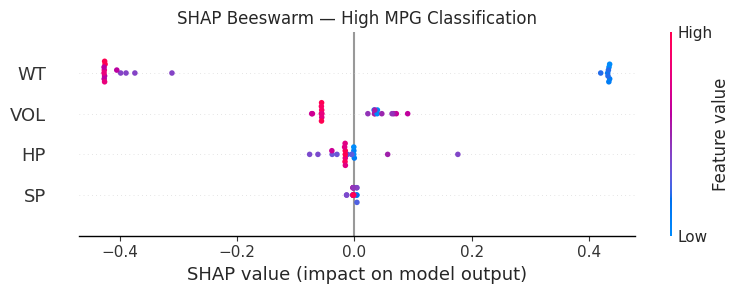


                         NEXT PLOT: SHAP FEATURE IMPORTANCE



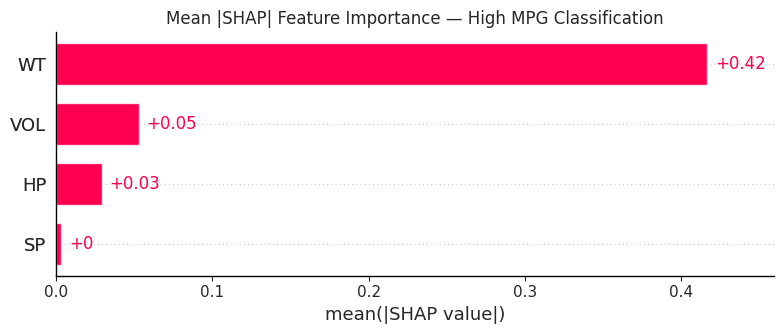

In [37]:

# === 7) SHAP: Beeswarm + Importance (with console gap) ===
# Robust, model-agnostic explainer; explain the probability for class=1
bg = X_train.sample(min(200, len(X_train)), random_state=0)
explainer = shap.explainers.Permutation(lambda X: clf.predict_proba(X)[:, 1], bg)
sv = explainer(X_test)

# 7a) Beeswarm
shap.plots.beeswarm(sv, max_display=12, show=False)
plt.title("SHAP Beeswarm — High MPG Classification", fontsize=12)
plt.tight_layout()
plt.savefig("shap_beeswarm_cls.png", dpi=300)
plt.show()

# Console gap between plots
print("\n" + "="*80)
print(" " * 25 + "NEXT PLOT: SHAP FEATURE IMPORTANCE")
print("="*80 + "\n")

# 7b) Mean |SHAP| bar (importance)
plt.figure(figsize=(7,5))
shap.plots.bar(sv, max_display=12, show=False)
plt.title("Mean |SHAP| Feature Importance — High MPG Classification", fontsize=12)
plt.tight_layout()
plt.savefig("shap_importance_cls.png", dpi=300)
plt.show()
